# Визуализация агрегации

In [32]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from disk_analyzer.models import DiskDataset
from Experiments import TIMES
from PredictionsAggregator import PredictionsAggregator
import pickle
import matplotlib.cm as cm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXP_NUM = 49
RES_FOLDER = os.path.join("Artifacts", f"Exp_{EXP_NUM}")
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
BATCH_SIZE = 1024
DATA = 'Preprocessed/30_10_test_preprocessed.csv'
AGG_MODE = 't_dist'
AGG_WEIGHT = 100

In [33]:
with open(os.path.join(MODELS_FOLDER, '4_SP_model.pkl'), 'rb') as f:
    model = pickle.load(f)

In [34]:
df_test = pd.read_csv(DATA)
print(df_test[df_test['failure'] == 0]['serial_number'].unique())
print(df_test[df_test['failure'] == 1]['serial_number'].unique())

['13H87YWAS' '13H8AB0GS' '13H8B3SGS' ... 'ZA18CCWM' 'ZCH05TTR' 'ZCH068F2']
['5732PE2OT' '96ICTBQIT' '9QM04GKZ' 'JK1101B9J301EF' 'JK1101B9JP60TU'
 'JK1104B8GGGBXW' 'JK1105B8GHWJZX' 'JK1105B8J10GXX' 'JK1105B8JS2ELX'
 'JK1131YAHP3NEV' 'JK1171YAK2045N' 'JK11A8B9J67Z0F' 'JK11A8B9J90WMF'
 'MJ0351YNG9Z5WA' 'MJ0351YNGA6Z8A' 'MJ1311YNG36USA' 'MJ1311YNG5XS1A'
 'MJ1311YNG733NA' 'MJ1311YNG7LWAA' 'MJ1313YNG0ZL2C' 'MJ1313YNG1VEUC'
 'MJ1321YNG09HRA' 'MJ1321YNG0JU6A' 'MK0311YHGEZB3A' 'MK0313YHGGJ4PC'
 'MK0333YHGPJERC' 'PL1301LAG3594H' 'PL1321LAG34N8H' 'PL1321LAGAXVMH'
 'PL1331LAGLXSHH' 'PL1331LAGRUENH' 'PL1331LAGRZ3DH' 'PL1331LAGS94VH'
 'PL1331LAGSDZXH' 'PL1331LAGSGR2H' 'PL1331LAGT941H' 'PL1331LAGTH4PH'
 'PL1331LAHBSRGH' 'PL1331LAHBXGDH' 'PL1331LAHD0UAH' 'PL1331LAHD10SH'
 'PL1331LAHD16PH' 'PL1331LAHD32MH' 'PL1331LAHD5SDH' 'PL1331LAHDDWUH'
 'PL1331LAHE0WLH' 'PL1331LAHE0X1H' 'PL1331LAHE1MDH' 'PL1331LAHESYPH'
 'PL1331LAHGVAUH' 'PL2331LAG9LE4J' 'PL2331LAG9RB7J' 'PL2331LAG9W4YJ'
 'PL2331LAGMZ8XJ' 'PL2331LA

In [41]:
def plot_predictions(X_pred, times, ax, shift_pred=True, max_times = np.inf):


    cmap = cm.viridis
    num_lines = len(X_pred)
    colors = [cmap(i / max(num_lines - 1, 1)) for i in range(num_lines)]
    max_time = X_pred['time'].max()

    times_str = set(map(str, times))
    times_cols = [col for col in X_pred.columns if str(col) in times_str]
    for i, (index, row) in enumerate(X_pred.iterrows()):
        
        if not shift_pred:
            cur_times = times[times < max_times]
            ax.plot(
                cur_times,
                row[times_cols].values[:len(cur_times)], 
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
        else:
            cur_times = times - (max_time - row.values[1])  
            ax.plot(
                cur_times[cur_times < max_times],
                row[times_cols].values[:len(cur_times[cur_times < max_times])], #TODO: до len() делать не вполне правильно, потом надо пофиксить
                color=colors[i],
                label=f'disk = {row.values[0]}, time = {row.values[1]}'
            )
    ax.set_title('Predictions')
    ax.grid(True)
    return ax

def plot_disk_predictions(X_pred, serial_number, last_observ_n, amount_observ, times, ax = None, shift_pred=True, X_gt = None, plot_event = True, max_times = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number]
    cur_X_pred = cur_X_pred.sort_values(by=['time']).head(last_observ_n).tail(amount_observ)
    ax = plot_predictions(cur_X_pred, times, ax, shift_pred=shift_pred, max_times = max_times)
    if X_gt is not None:
        if plot_event:
            cur_X_gt = X_gt[X_gt['serial_number'] == serial_number] 
            last_time = cur_X_pred.iloc[-1, 1]
            last_duration = cur_X_gt[cur_X_gt['time'] == last_time]['duration'].values[0]
            event = cur_X_gt['failure'].max() == True
            plot_event_line(last_duration, event, ax, TICK_SIZE)
    return ax

def plot_event_line(time, event, ax, fontsize=TICK_SIZE):
    event_color = 'r' if event else 'b'
    ax.axvline(x=time, color=event_color, linestyle='--', linewidth=2)

    # Подописываем момент исхода
    x_fraction = ax.transData.transform((time, 0))[0]
    x_fraction = ax.transAxes.inverted().transform((x_fraction, 0))[0]

    ax.annotate(
        f'{time}',
        xy=(x_fraction, -0.05),       
        xycoords='axes fraction',
        ha='center',
        va='top',
        fontsize=fontsize,
        color=event_color
    )

def get_chain_survival_predictions_for_disk(
    X_pred,
    serial_number,
    times,
    sample_grid,
    pred_agg,
    agg_method,
    agg_weight,
    X_gt=None,
    last_observ_n=None
):
    cur_X_pred = X_pred[X_pred['serial_number'] == serial_number].sort_values(by=['time'])

    if last_observ_n is not None:
        cur_X_pred = cur_X_pred.head(last_observ_n)

    max_chain_len = cur_X_pred.shape[0]
    rows = []
    event = None
    duration = None

    for chain_len in sample_grid:
        if chain_len > max_chain_len:
            continue

        chain = cur_X_pred.tail(chain_len)
        timeshift = chain['time'].max() - chain['time']

        aggregated_pred = pred_agg.predict(chain, times, timeshift=timeshift)
        times_str = set(map(str, times))
        times_cols = [col for col in aggregated_pred.columns if str(col) in times_str]
        survival_curve = aggregated_pred[times_cols].iloc[0].values

        rows.append({
            'chain_len': chain_len,
            'agg_method': agg_method,
            'agg_weight': agg_weight,
            'survival': survival_curve
        })

        if X_gt is not None and event is None and duration is None:
            cur_X_gt = X_gt.loc[cur_X_pred.index]
            event = cur_X_gt['failure'].max()
            duration = cur_X_gt['duration'].min()

    return pd.DataFrame(rows), event, duration


def plot_survival_chains(df, times, ax=None, plot_event=False, event=None, duration=None, max_times = np.inf):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    num_lines = len(df)
    cmap = cm.plasma
    colors = [cmap(i / max(num_lines-1, 1)) for i in range(num_lines)]

    for i, row in enumerate(df.itertuples()):
        ax.plot(times[times < max_times], row.survival[times < max_times], color=colors[i], label=f'len={row.chain_len}', linewidth=2)

    method = df['agg_method'].iloc[0]
    weight = df['agg_weight'].iloc[0]

    if plot_event:
        if event is not None and duration is not None:
            plot_event_line(duration, event, ax=ax)
        else:
            print(f' event = {event} or duration = {duration} is None')

    ax.set_title(f'{method}, weight={weight}', fontsize=14)
    ax.set_xlabel('Time')
    ax.set_ylabel('Survival probability')
    ax.legend(title='Chain length')
    ax.grid(True)
    return ax



In [36]:
def make_predictions(data:str, pred_agg, times = TIMES):
    df_test = pd.read_csv(data)
    df_test = df_test[df_test['time'] != df_test['max_lifetime']]
    extended_times = pred_agg.get_extended_times(df_test, times = times)
    dl = DataLoader(dataset = DiskDataset('score', [data]),
        batch_size = BATCH_SIZE)
    X_pred, X_gt = model.predict(dl, times=extended_times)
    return X_pred, X_gt

In [37]:
pred_agg = PredictionsAggregator(mode=AGG_MODE, weight=AGG_WEIGHT)
X_pred, X_gt = make_predictions(DATA, pred_agg, TIMES)
extended_times = pred_agg.get_extended_times(X_pred, times=TIMES)

100%|██████████| 43/43 [01:19<00:00,  1.85s/it]


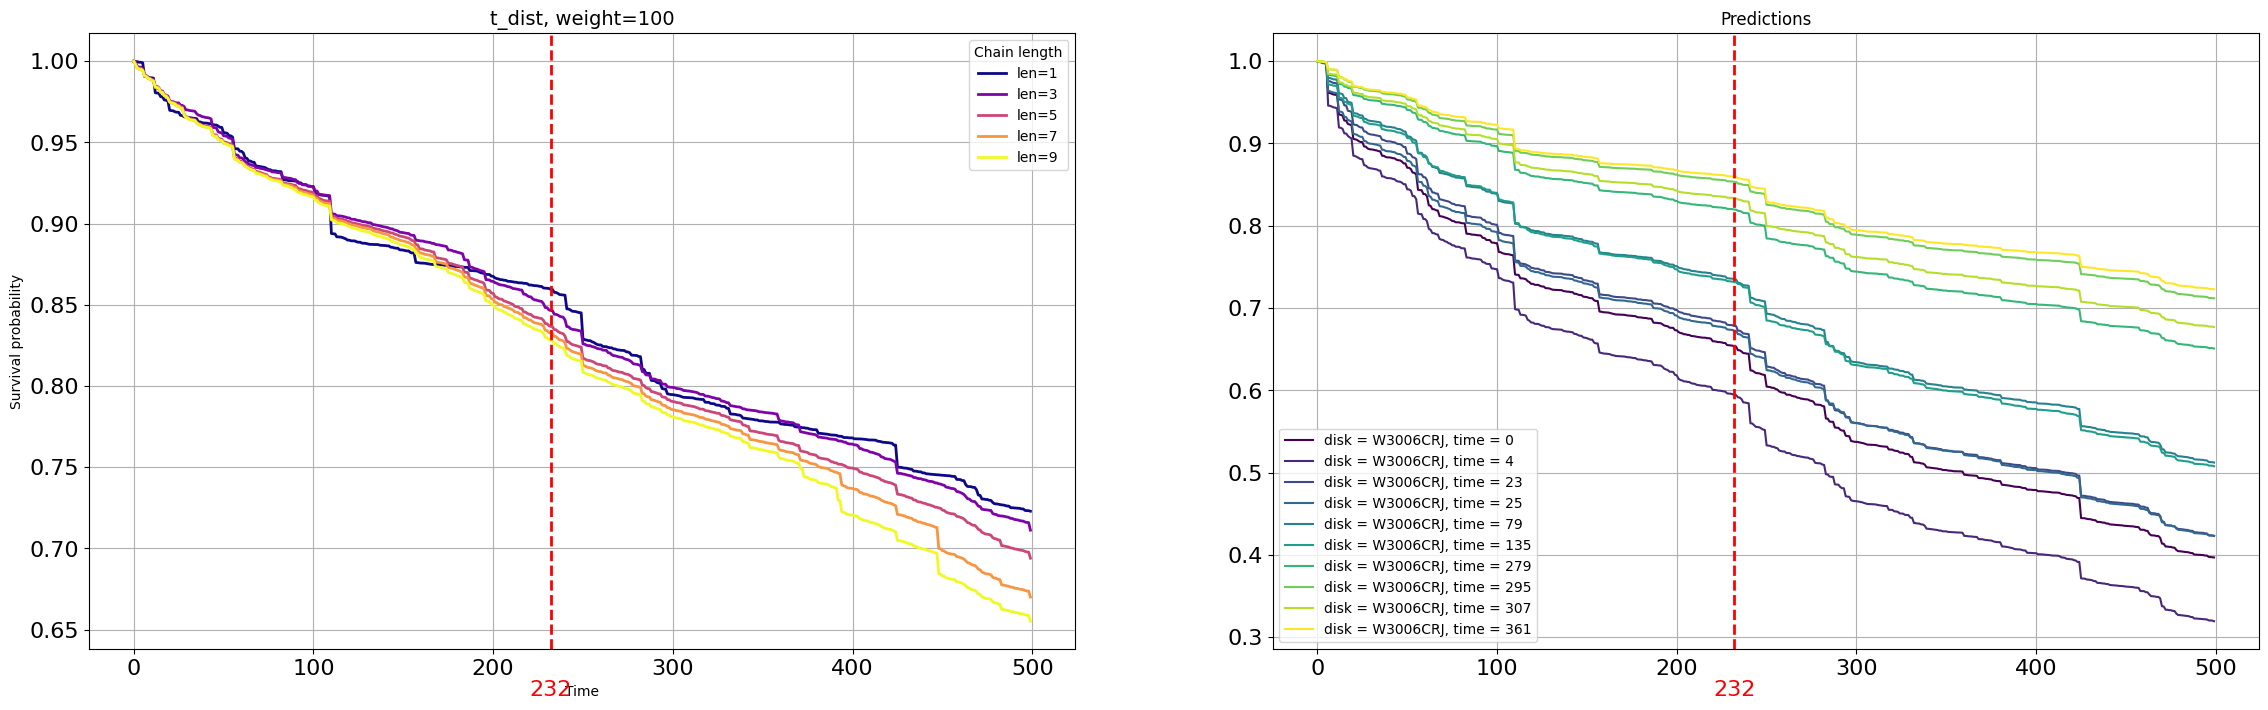

In [42]:
TICK_SIZE = 16
fig, axes = plt.subplots(1, 2, figsize=(28, 8))
axes[0].tick_params(labelsize=TICK_SIZE)
axes[1].tick_params(labelsize=TICK_SIZE)

LAST_OBSERV_N = 10
SERIAL_NUMBER = 'W3006CRJ'

plot_disk_predictions(X_pred, SERIAL_NUMBER, LAST_OBSERV_N, 10,  TIMES, ax= axes[1], shift_pred=False, X_gt=X_gt, max_times = 500)
df, event, duration = get_chain_survival_predictions_for_disk(
    X_pred, SERIAL_NUMBER, TIMES, sample_grid=range(1, 10, 2), 
    pred_agg=pred_agg, agg_method=AGG_MODE, agg_weight=AGG_WEIGHT, X_gt = X_gt, last_observ_n=LAST_OBSERV_N
)
plot_survival_chains(df, TIMES, ax= axes[0], plot_event = True, duration = duration, event = event, max_times = 500)
plt.legend()

<Axes: title={'center': 't_dist, weight=100'}, xlabel='Time', ylabel='Survival probability'>

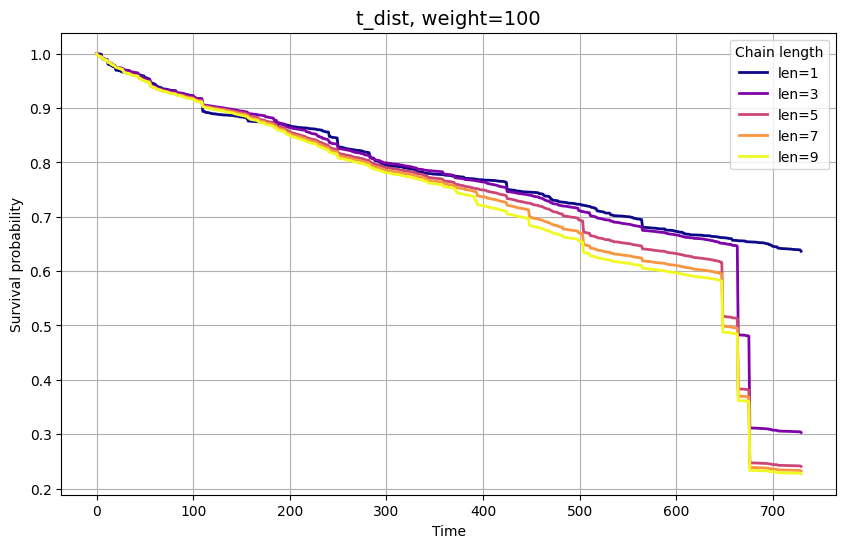

In [39]:

plot_survival_chains(df, TIMES)